In [3]:
# Connecting Google Drive with Google Colab
# from google.colab import drive
# drive.mount('/content/drive/')

In [15]:
#importing essential libraries

!pip install nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import nltk
from nltk.corpus import stopwords



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
#df = pd.read_csv('C:\\Users\\ankit\\Desktop\\DataSet Collection\\amazon_reviews.csv')

In [17]:
df = pd.read_csv("../data/amazon_reviews.csv")

df.head()

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4,No issues.,23/07/2014,138,0,0,0,0,0.0,0.0
1,1,0mie,5,"Purchased this for my device, it worked as adv...",25/10/2013,409,0,0,0,0,0.0,0.0
2,2,1K3,4,it works as expected. I should have sprung for...,23/12/2012,715,0,0,0,0,0.0,0.0
3,3,1m2,5,This think has worked out great.Had a diff. br...,21/11/2013,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5,"Bought it with Retail Packaging, arrived legit...",13/07/2013,513,0,0,0,0,0.0,0.0


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            4915 non-null   int64  
 1   reviewerName          4914 non-null   str    
 2   overall               4915 non-null   int64  
 3   reviewText            4914 non-null   str    
 4   reviewTime            4915 non-null   str    
 5   day_diff              4915 non-null   int64  
 6   helpful_yes           4915 non-null   int64  
 7   helpful_no            4915 non-null   int64  
 8   total_vote            4915 non-null   int64  
 9   score_pos_neg_diff    4915 non-null   int64  
 10  score_average_rating  4915 non-null   float64
 11  wilson_lower_bound    4915 non-null   float64
dtypes: float64(2), int64(7), str(3)
memory usage: 460.9 KB


In [19]:
df.isnull().sum()

Unnamed: 0              0
reviewerName            1
overall                 0
reviewText              1
reviewTime              0
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
dtype: int64

In [20]:
df.columns

Index(['Unnamed: 0', 'reviewerName', 'overall', 'reviewText', 'reviewTime',
       'day_diff', 'helpful_yes', 'helpful_no', 'total_vote',
       'score_pos_neg_diff', 'score_average_rating', 'wilson_lower_bound'],
      dtype='str')

In [21]:
df = df.rename(columns={
    "overall": "rating",
    "reviewText": "review"
})

In [22]:
df.columns

Index(['Unnamed: 0', 'reviewerName', 'rating', 'review', 'reviewTime',
       'day_diff', 'helpful_yes', 'helpful_no', 'total_vote',
       'score_pos_neg_diff', 'score_average_rating', 'wilson_lower_bound'],
      dtype='str')

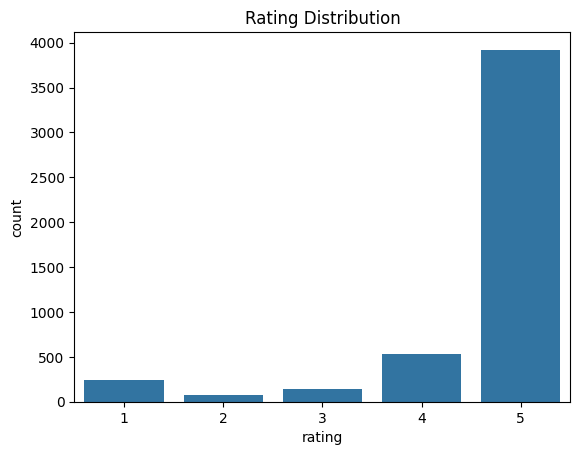

In [23]:
sns.countplot(x=df['rating'])
plt.title("Rating Distribution")
plt.show()

In [24]:
def sentiment_label(rating):
    
    if rating >= 4:
        return "positive"
    
    elif rating <= 2:
        return "negative"
    
    else:
        return "neutral"



In [27]:
df[['rating','sentiment']].head()

KeyError: "['sentiment'] not in index"

In [28]:
df = df[['review','rating','sentiment']]

KeyError: "['sentiment'] not in index"

In [29]:
df.head()

,Unnamed: 0,reviewerName,rating,review,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4,No issues.,23/07/2014,138,0,0,0,0,0.0,0.0
1,1,0mie,5,"Purchased this for my device, it worked as adv...",25/10/2013,409,0,0,0,0,0.0,0.0
2,2,1K3,4,it works as expected. I should have sprung for...,23/12/2012,715,0,0,0,0,0.0,0.0
3,3,1m2,5,This think has worked out great.Had a diff. br...,21/11/2013,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5,"Bought it with Retail Packaging, arrived legit...",13/07/2013,513,0,0,0,0,0.0,0.0


In [30]:
df["sentiment"] = df["rating"].apply(sentiment_label)

In [31]:
import nltk
from nltk.corpus import stopwords

In [32]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ankit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [33]:
import re

stop_words = set(stopwords.words("english"))

def clean_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()

    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [34]:
df["clean_review"] = df["review"].apply(clean_text)

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_review"])

In [36]:
from sklearn.model_selection import train_test_split

y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9277721261444557
              precision    recall  f1-score   support

    negative       0.90      0.37      0.53        70
     neutral       0.00      0.00      0.00        25
    positive       0.93      1.00      0.96       888

    accuracy                           0.93       983
   macro avg       0.61      0.46      0.50       983
weighted avg       0.90      0.93      0.91       983



C:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [39]:
import pickle

pickle.dump(model, open("outputs/sentiment_model.pkl", "wb"))

In [40]:
import os

os.makedirs("outputs", exist_ok=True)

In [41]:
#import pickle

#pickle.dump(model, open("outputs/sentiment_model.pkl", "wb"))

In [42]:
#os.listdir("outputs")

In [43]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

In [44]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier()
}

results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc
    
    print(name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    print("----------------------------")

Logistic Regression
Accuracy: 0.9277721261444557
              precision    recall  f1-score   support

    negative       0.90      0.37      0.53        70
     neutral       0.00      0.00      0.00        25
    positive       0.93      1.00      0.96       888

    accuracy                           0.93       983
   macro avg       0.61      0.46      0.50       983
weighted avg       0.90      0.93      0.91       983

----------------------------
Naive Bayes
Accuracy: 0.9033570701932858
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        70
     neutral       0.00      0.00      0.00        25
    positive       0.90      1.00      0.95       888

    accuracy                           0.90       983
   macro avg       0.30      0.33      0.32       983
weighted avg       0.82      0.90      0.86       983

----------------------------
SVM
Accuracy: 0.9399796541200407


C:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

              precision    recall  f1-score   support

    negative       0.84      0.61      0.71        70
     neutral       0.25      0.04      0.07        25
    positive       0.95      0.99      0.97       888

    accuracy                           0.94       983
   macro avg       0.68      0.55      0.58       983
weighted avg       0.92      0.94      0.93       983

----------------------------
Decision Tree
Accuracy: 0.884028484231943
              precision    recall  f1-score   support

    negative       0.37      0.33      0.35        70
     neutral       0.13      0.08      0.10        25
    positive       0.93      0.95      0.94       888

    accuracy                           0.88       983
   macro avg       0.48      0.45      0.46       983
weighted avg       0.87      0.88      0.88       983

----------------------------


In [45]:
import pandas as pd

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.927772
1          Naive Bayes  0.903357
2                  SVM  0.939980
3        Decision Tree  0.884028


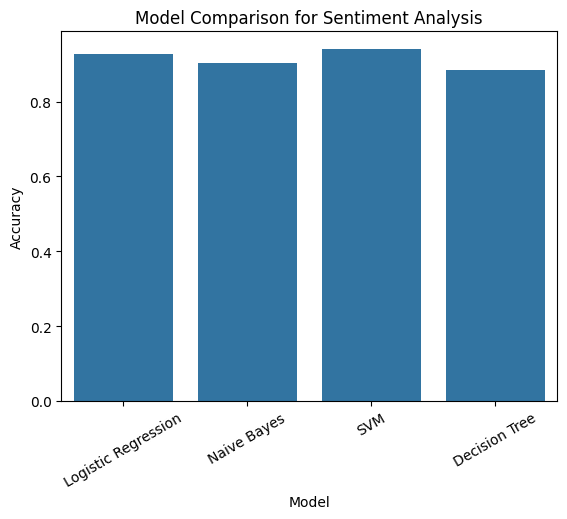

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Model", y="Accuracy", data=results_df)

plt.title("Model Comparison for Sentiment Analysis")

plt.xticks(rotation=30)

plt.show()

In [47]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [49]:
best_model = models["SVM"]

y_pred = best_model.predict(X_test)

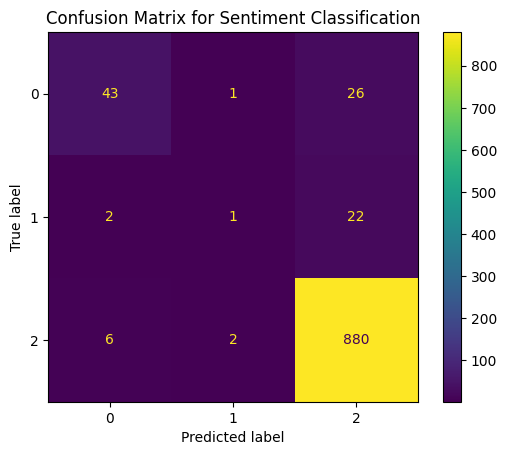

In [50]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix for Sentiment Classification")

plt.show()

In [52]:
import os
import pickle

os.makedirs("outputs", exist_ok=True)

with open("outputs/sentiment_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [53]:
with open("outputs/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)